In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.pipeline import FunctionTransformer

import seaborn as sns
import warnings
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.components import connected_components

warnings.filterwarnings("ignore")

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA


from sklearn.preprocessing import PowerTransformer

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    classification_report,
)

print("Biblioteki załadowane.")

Biblioteki załadowane.


In [153]:
from ucimlrepo import fetch_ucirepo

polish_companies_bankruptcy = fetch_ucirepo(id=365)

X = polish_companies_bankruptcy.data.features
y = polish_companies_bankruptcy.data.targets

- check number of companies in each year

In [154]:
X.head()

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A55,A56,A57,A58,A59,A60,A61,A62,A63,A64
0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,...,348690.0,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277
1,1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,...,2304.6,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870
2,1,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,...,6332.7,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078
3,1,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,...,20545.0,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497
4,1,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,...,3186.6,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980


In [155]:
y.head()

,class
0,0
1,0
2,0
3,0
4,0


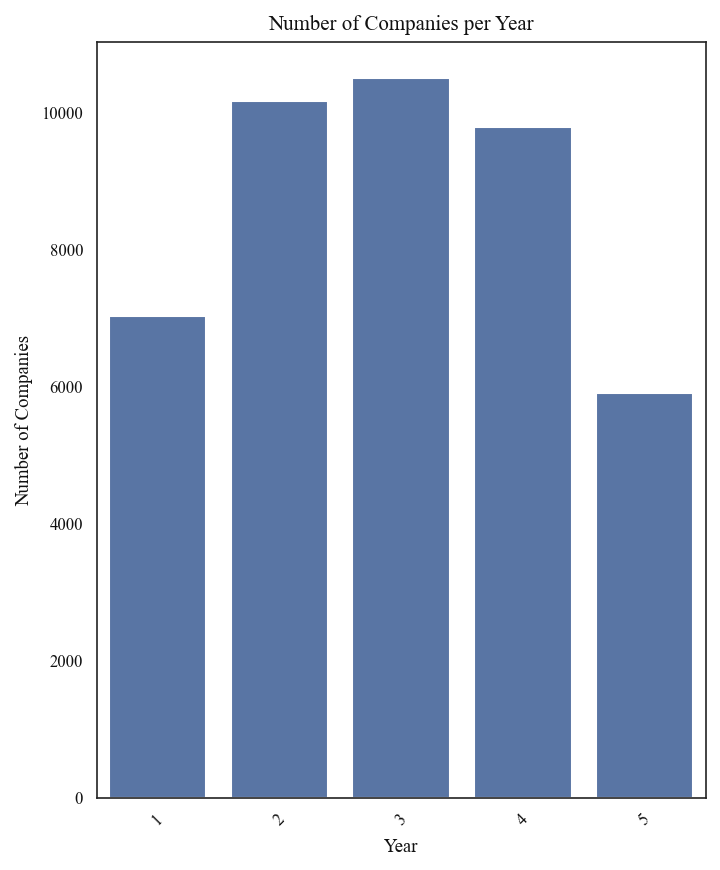

In [156]:
years = X["year"].unique()
counts = X["year"].value_counts().sort_index()

plt.figure(figsize=(5, 6))
sns.barplot(x=years, y=counts.values)
plt.title("Number of Companies per Year")
plt.xlabel("Year")
plt.ylabel("Number of Companies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- filter data for 3 only

In [157]:
mask_2010 = X["year"] == 3

X = X[mask_2010].drop(columns=["year"])
y = y[mask_2010]

In [158]:
X["class"] = y

In [159]:
X.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
count,10503.000000,10503.000000,10503.000000,10485.000000,1.047800e+04,10503.000000,10503.000000,10489.000000,10500.000000,10503.000000,...,10460.000000,10503.000000,10474.000000,10503.000000,9.911000e+03,10486.000000,1.046000e+04,10485.000000,10275.000000,10503.000000
mean,0.052844,0.619911,0.095490,9.980499,-1.347355e+03,-0.121159,0.065624,19.140113,1.819254,0.366093,...,-0.530082,-0.014817,3.848794,1.429319,5.713958e+02,13.935361,1.348668e+02,9.095149,35.766800,0.047129
std,0.647797,6.427041,6.420056,523.691951,1.185517e+05,6.970625,0.651152,717.756745,7.581659,6.428603,...,55.978608,18.684047,190.201224,77.273270,3.715816e+04,83.704103,2.600764e+04,31.419096,428.298315,0.211926
min,-17.692000,0.000000,-479.730000,0.002080,-1.190000e+07,-508.120000,-17.692000,-2.081800,-1.215700,-479.730000,...,-5691.700000,-1667.300000,-198.690000,-172.070000,0.000000e+00,-6.590300,-2.340000e+06,-0.000156,-0.000102,0.000000
25%,0.000686,0.253955,0.017461,1.040100,-5.207075e+01,0.000000,0.002118,0.431270,1.011275,0.297340,...,0.005137,0.006796,0.875560,0.000000,5.533150e+00,4.486075,4.073700e+01,3.062800,2.023350,0.000000
50%,0.043034,0.464140,0.198560,1.605600,1.579300e+00,0.000000,0.050945,1.111000,1.199000,0.515500,...,0.051765,0.106880,0.953060,0.002976,9.952100e+00,6.677300,7.066400e+01,5.139200,4.059300,0.000000
75%,0.123805,0.689330,0.419545,2.959500,5.608400e+01,0.072584,0.142275,2.857100,2.059100,0.725635,...,0.130010,0.271310,0.995927,0.240320,2.093600e+01,10.587500,1.182200e+02,8.882600,9.682750,0.000000
max,52.652000,480.730000,17.708000,53433.000000,6.850000e+05,45.533000,52.652000,53432.000000,740.440000,11.837000,...,293.150000,552.640000,18118.000000,7617.300000,3.660000e+06,4470.400000,1.070000e+06,1974.500000,21499.000000,1.000000


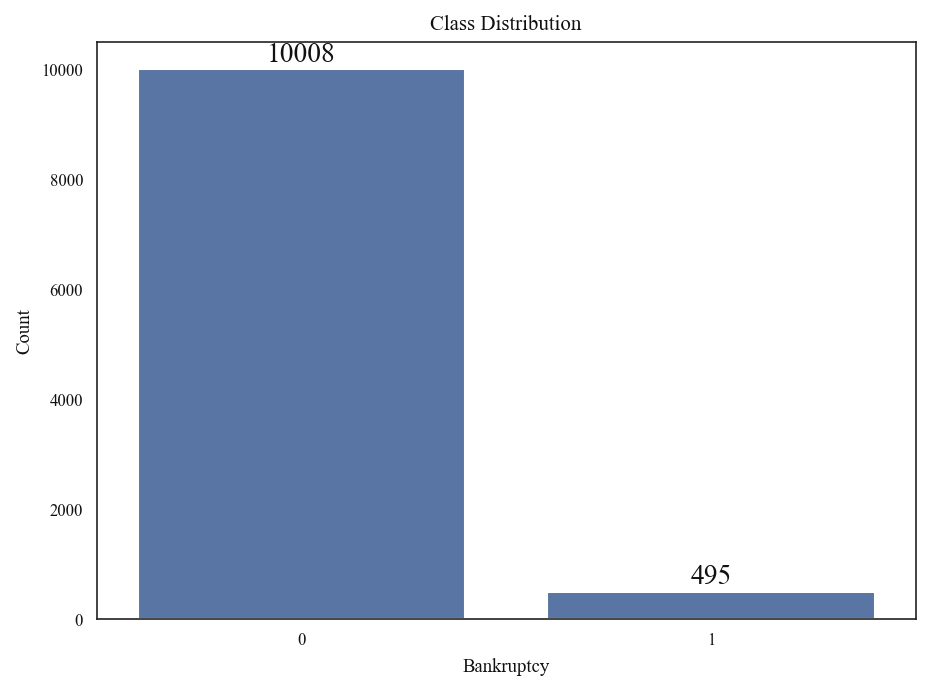

In [160]:
sns.countplot(data=y, x="class")
plt.title("Class Distribution")
plt.xlabel("Bankruptcy")
plt.ylabel("Count")
ax = plt.gca()
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 1),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

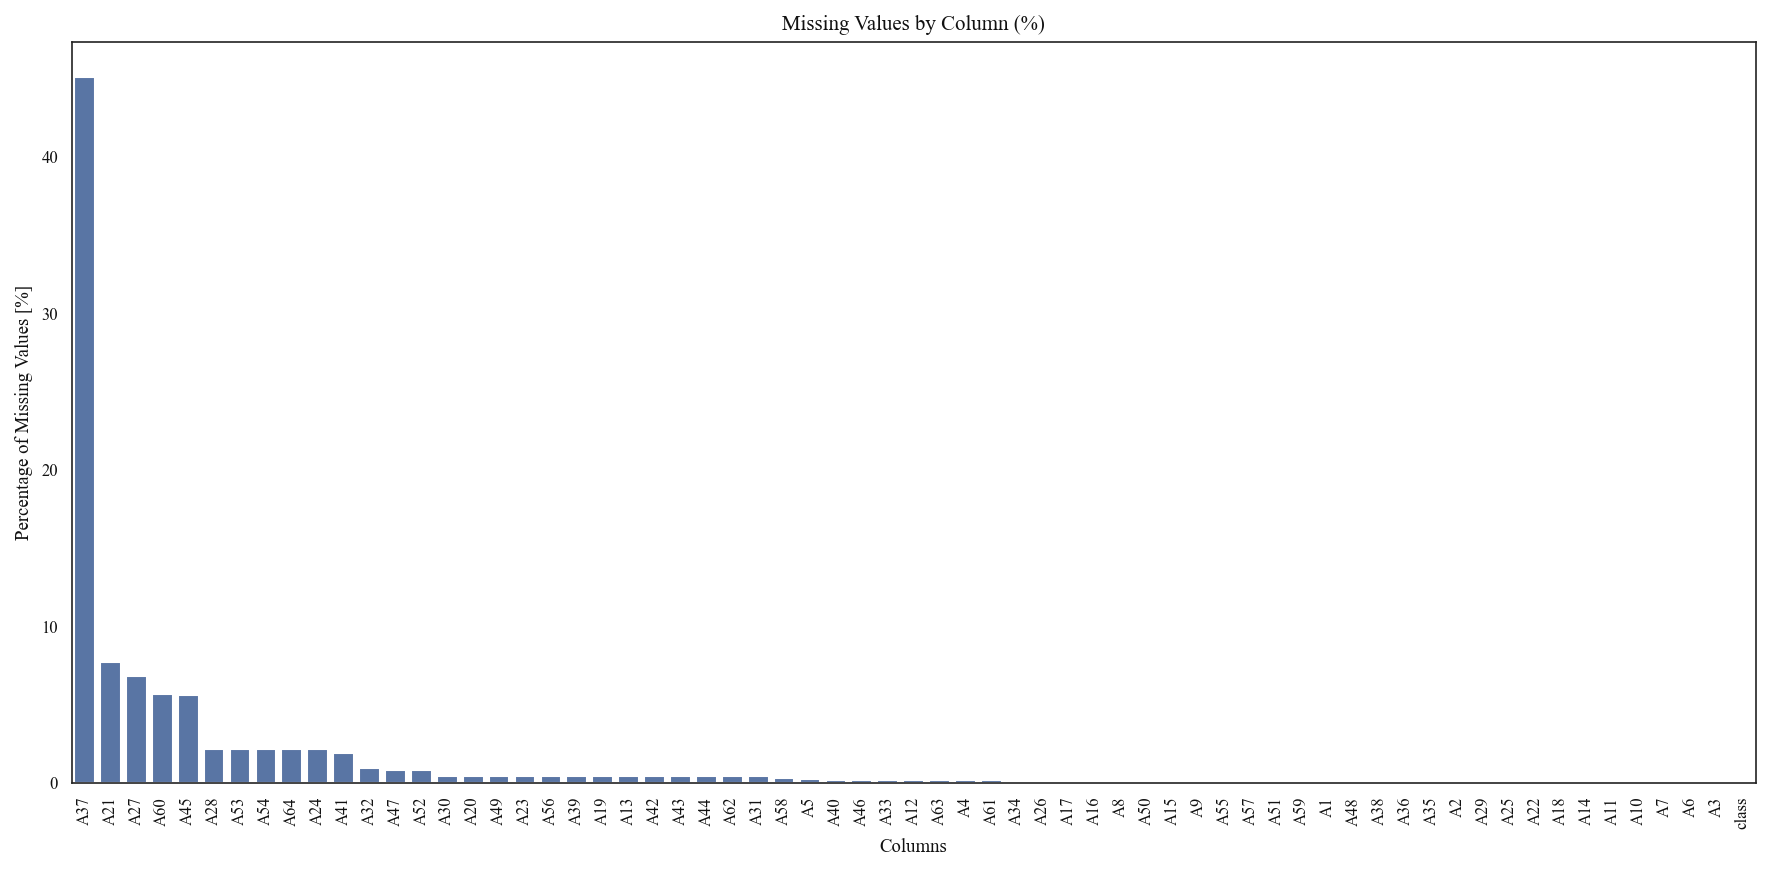

In [161]:
missing_values = X.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_values / len(X)) * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=missing_pct.index, y=missing_pct.values)
plt.xticks(rotation=90)
plt.title("Missing Values by Column (%)")
plt.xlabel("Columns")
plt.ylabel("Percentage of Missing Values [%]")
plt.tight_layout()
plt.show()

In [162]:
X = X.drop(columns=["A37"])

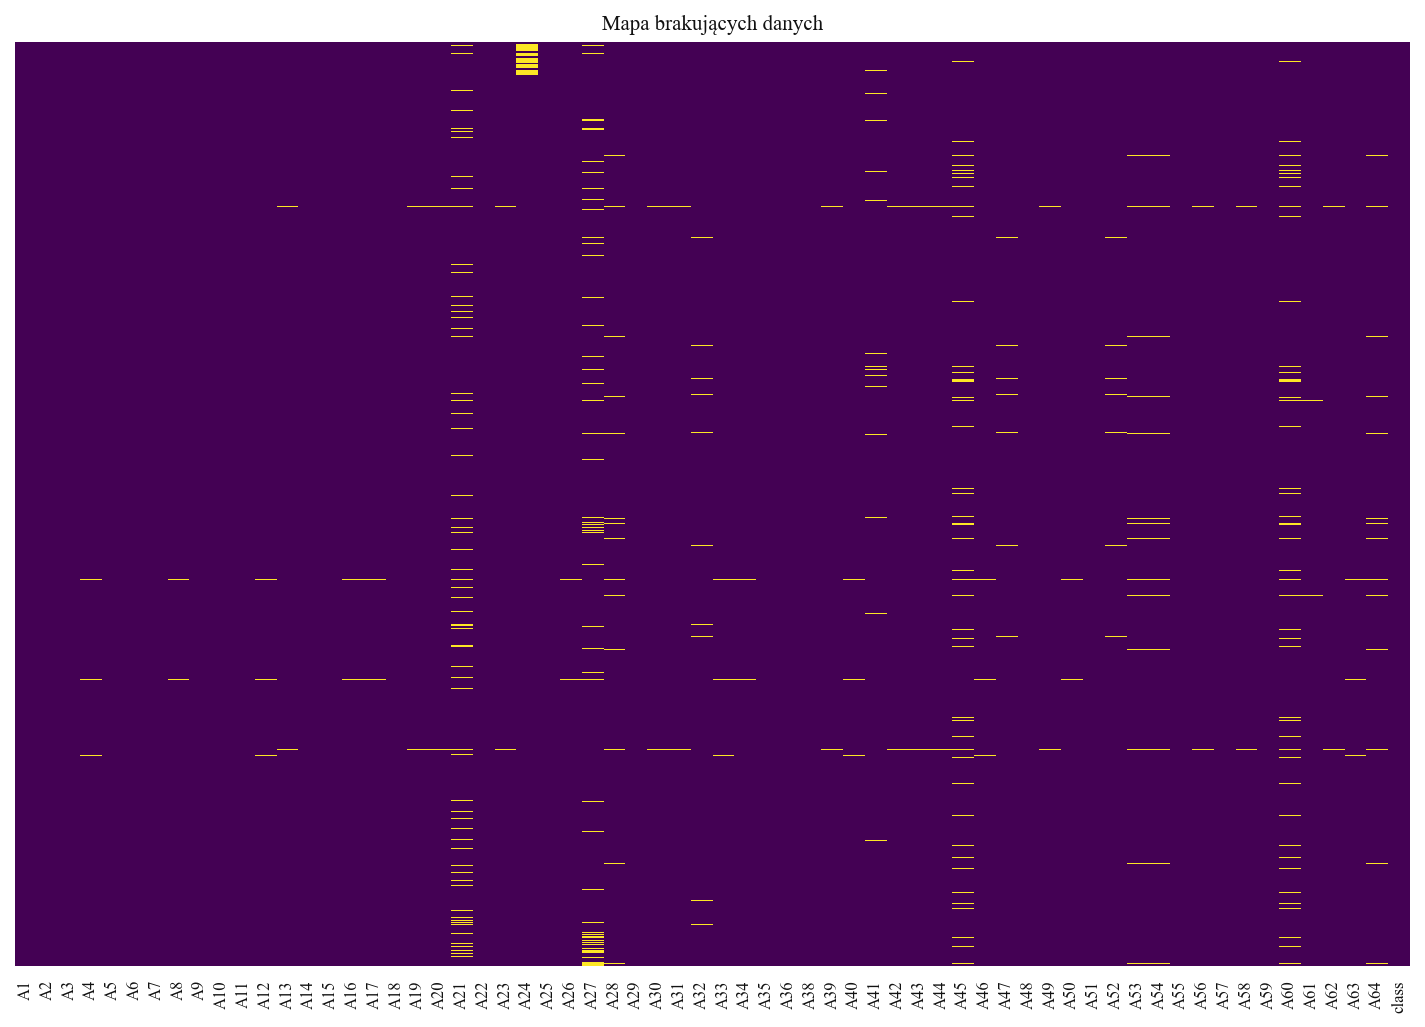

In [163]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Mapa brakujących danych")
plt.show()

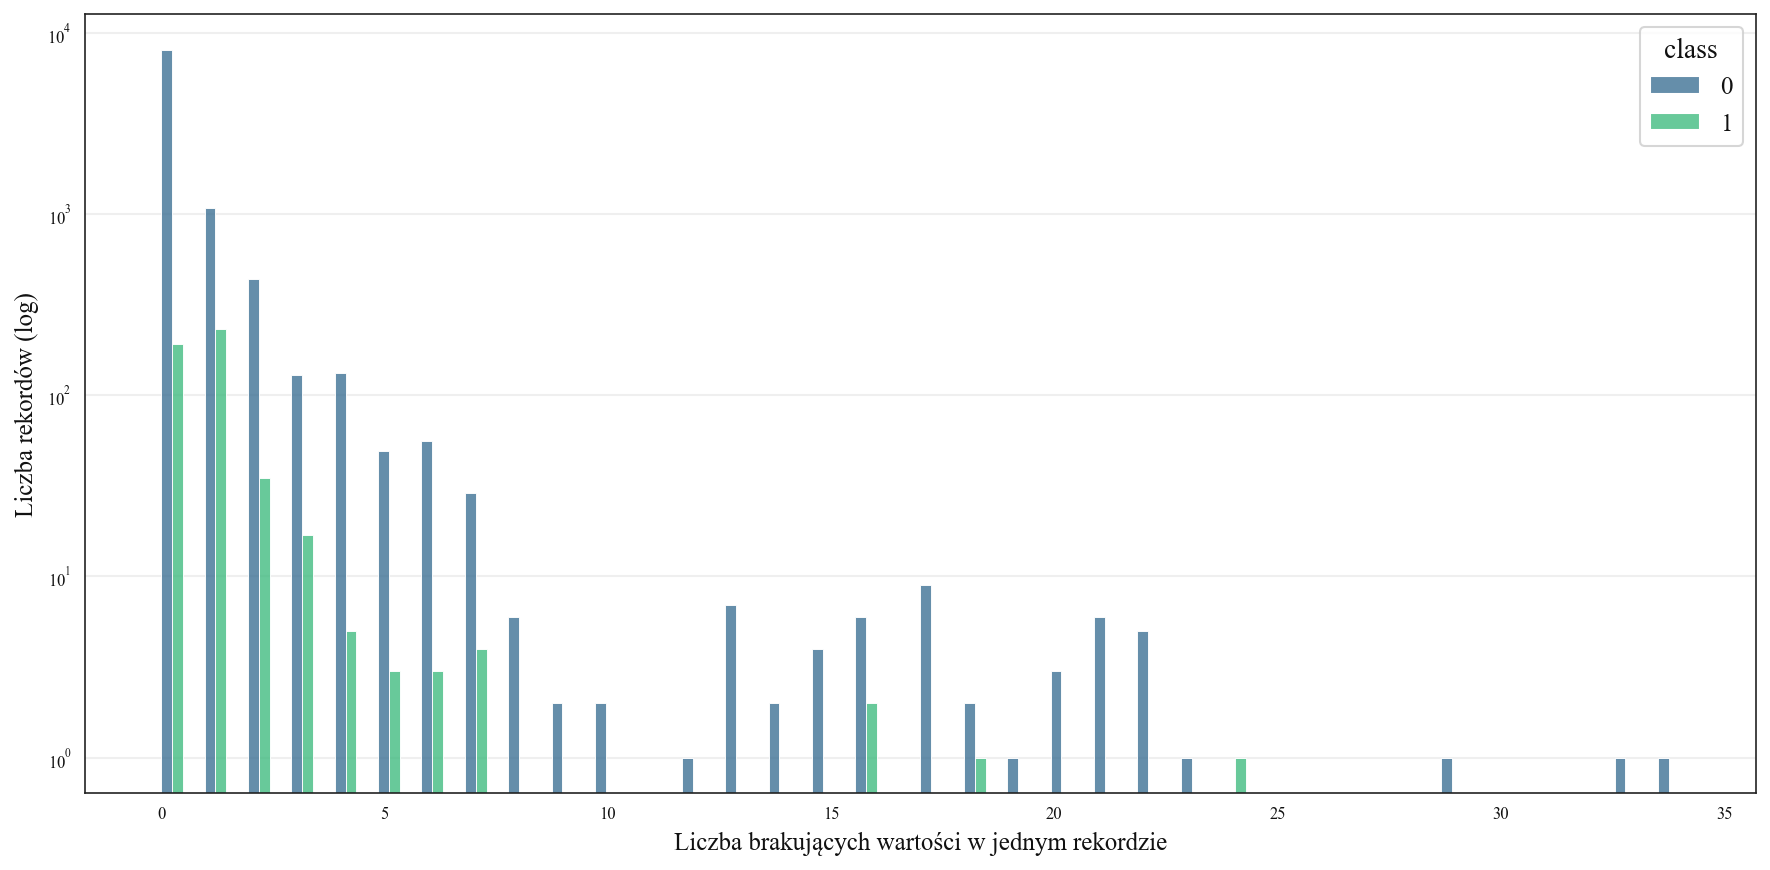

In [164]:
X["missing_count"] = X.drop(columns=["class"]).isnull().sum(axis=1)

plt.figure(figsize=(12, 6))

sns.histplot(
    data=X,
    x="missing_count",
    hue="class",
    bins=70,
    kde=False,
    palette="viridis",
    multiple="dodge",
)

plt.xlabel("Liczba brakujących wartości w jednym rekordzie", fontsize=12)
plt.ylabel("Liczba rekordów (log)", fontsize=12)

plt.yscale("log")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

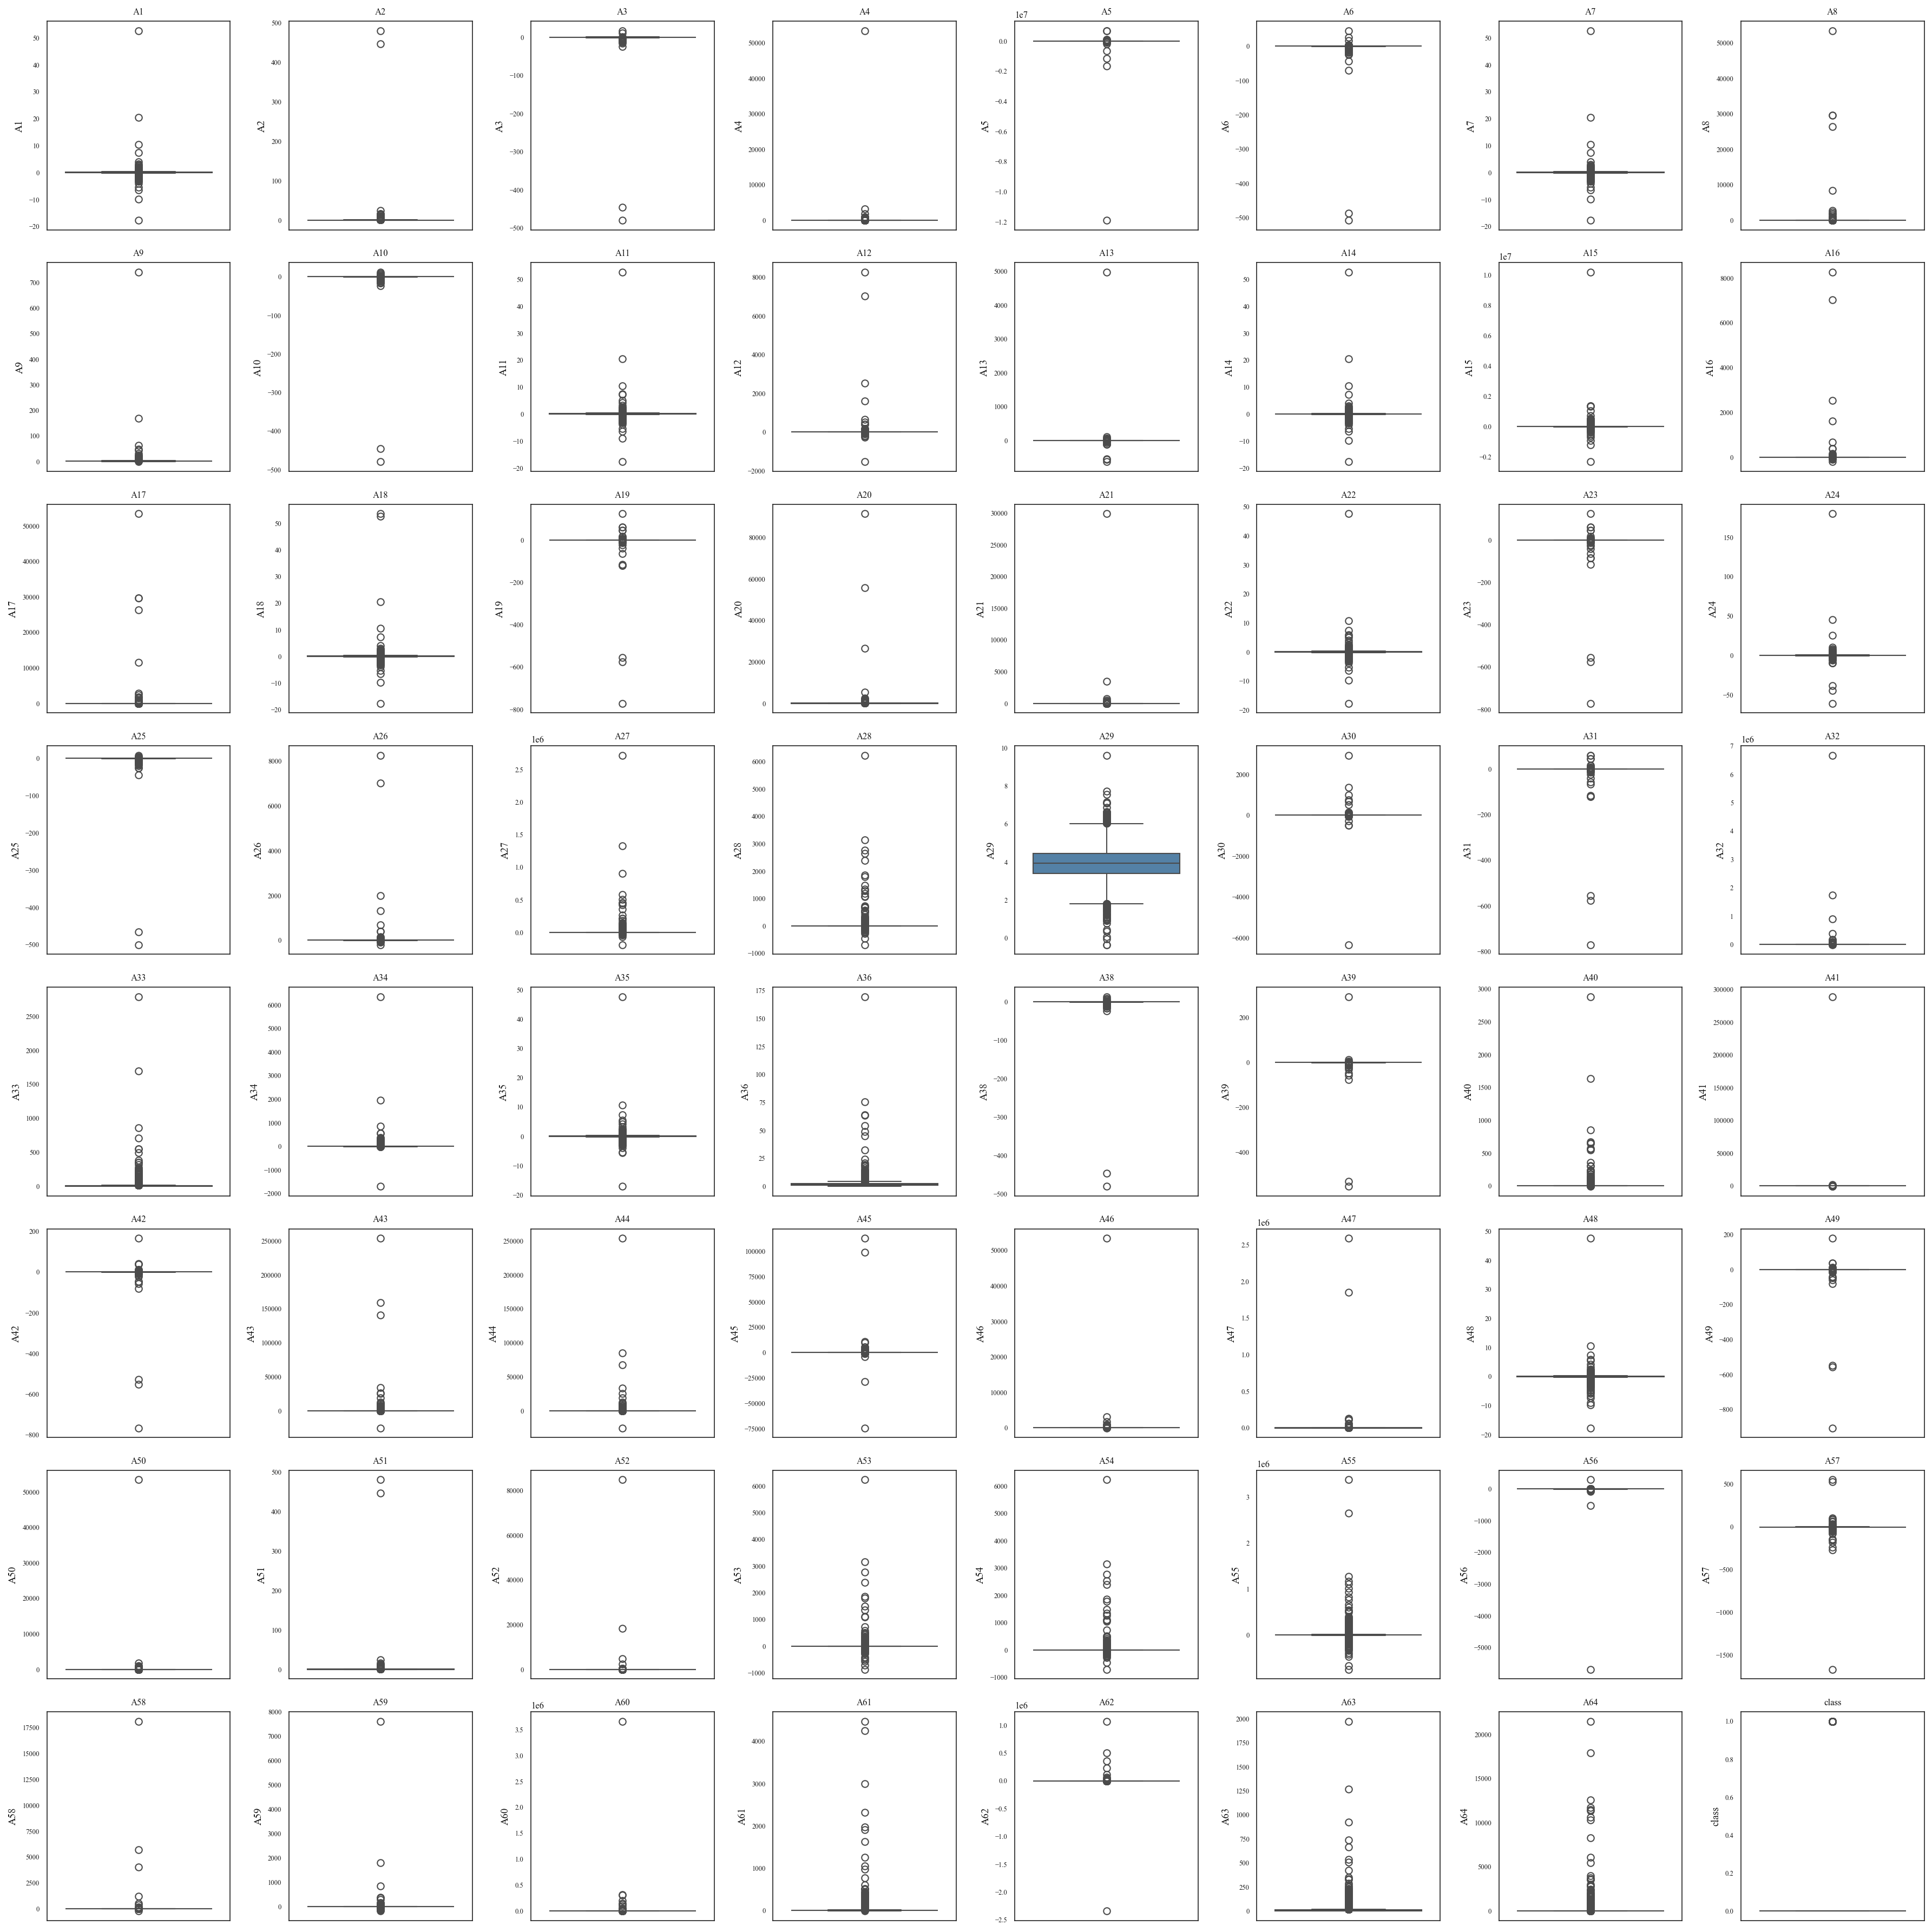

In [165]:
X = X.drop(columns=["missing_count"])
cols = X.columns
n_cols = 8
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(n_cols * 3, n_rows * 3))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=X[col], color="steelblue")
    plt.title(col, fontsize=8)
    plt.xticks([])
    plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()

___

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X.drop(columns=["class"]),
    X["class"],
    test_size=0.2,
    stratify=X["class"],
    random_state=42,
)

In [167]:
proportion_train = y_train.value_counts(normalize=True).sort_index()
proportion_test = y_test.value_counts(normalize=True).sort_index()

comparison = pd.concat(
    [proportion_train.rename("train"), proportion_test.rename("test")], axis=1
).fillna(0)

comparison["diff_pp"] = (abs(comparison["train"] - comparison["test"])) * 100

print("Porównanie proporcji klas")
print((comparison * 100).round(2))

max_diff = comparison["diff_pp"].abs().max()

Porównanie proporcji klas
       train   test  diff_pp
class                       
0      95.29  95.29     0.11
1       4.71   4.71     0.11


___

In [168]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.nanpercentile(X, 25, axis=0)
        Q3 = np.nanpercentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.k * IQR
        self.upper_ = Q3 + self.k * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)


class PassthroughTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.n_features_in_ = np.array(X).shape[1]
        return self

    def transform(self, X, y=None):
        return np.array(X, dtype=float)

In [169]:
def build_outlier_profile_by_class(X_df, y_ser, k=1.5):
    Xw = X_df.reset_index(drop=True)
    yw = pd.Series(y_ser).astype(int).reset_index(drop=True)

    q1 = Xw.quantile(0.25)
    q3 = Xw.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr

    outlier_mask = ((Xw.lt(lower)) | (Xw.gt(upper))) & Xw.notna()
    outlier_count = outlier_mask.sum(axis=1)

    outlier_df = pd.DataFrame(
        {
            "class": yw,
            "class_label": yw.astype(str),
            "outlier_count": outlier_count,
        }
    )
    outlier_df["has_outlier"] = (outlier_df["outlier_count"] > 0).astype(int)

    summary = (
        outlier_df.groupby("class", as_index=False)
        .agg(
            n_samples=("class", "size"),
            outlier_rows=("has_outlier", "sum"),
            avg_outliers_per_row=("outlier_count", "mean"),
            median_outliers_per_row=("outlier_count", "median"),
        )
        .sort_values("class")
    )
    summary["outlier_rows_pct"] = 100 * summary["outlier_rows"] / summary["n_samples"]
    return outlier_df, summary


outlier_df, summary = build_outlier_profile_by_class(X_train, y_train, k=1.5)

In [170]:
summary.round(3)

,class,n_samples,outlier_rows,avg_outliers_per_row,median_outliers_per_row,outlier_rows_pct
0,0,8006,7126,6.599,4.0,89.008
1,1,396,365,8.366,4.0,92.172


In [171]:
IMPUTERS = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "knn": KNNImputer(n_neighbors=5),
}

OUTLIERS = {
    "none": PassthroughTransformer(),
    "IQR_clip": IQRClipper(k=1.5),
    "log_transform": FunctionTransformer(np.log1p, validate=True),
}

SCALERS = {
    "none": PassthroughTransformer(),
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}

MODELS = {
    "logistic_regression": LogisticRegression(random_state=42),
    "decision_tree": DecisionTreeClassifier(random_state=42),
}

In [172]:
missing_counts = X_train.isnull().sum()
top_k = 6
top_k_features = missing_counts.sort_values(ascending=False).head(top_k).index.tolist()
print(f"Top {top_k} features with most missing values: {top_k_features}")

Top 6 features with most missing values: ['A21', 'A27', 'A60', 'A45', 'A24', 'A64']


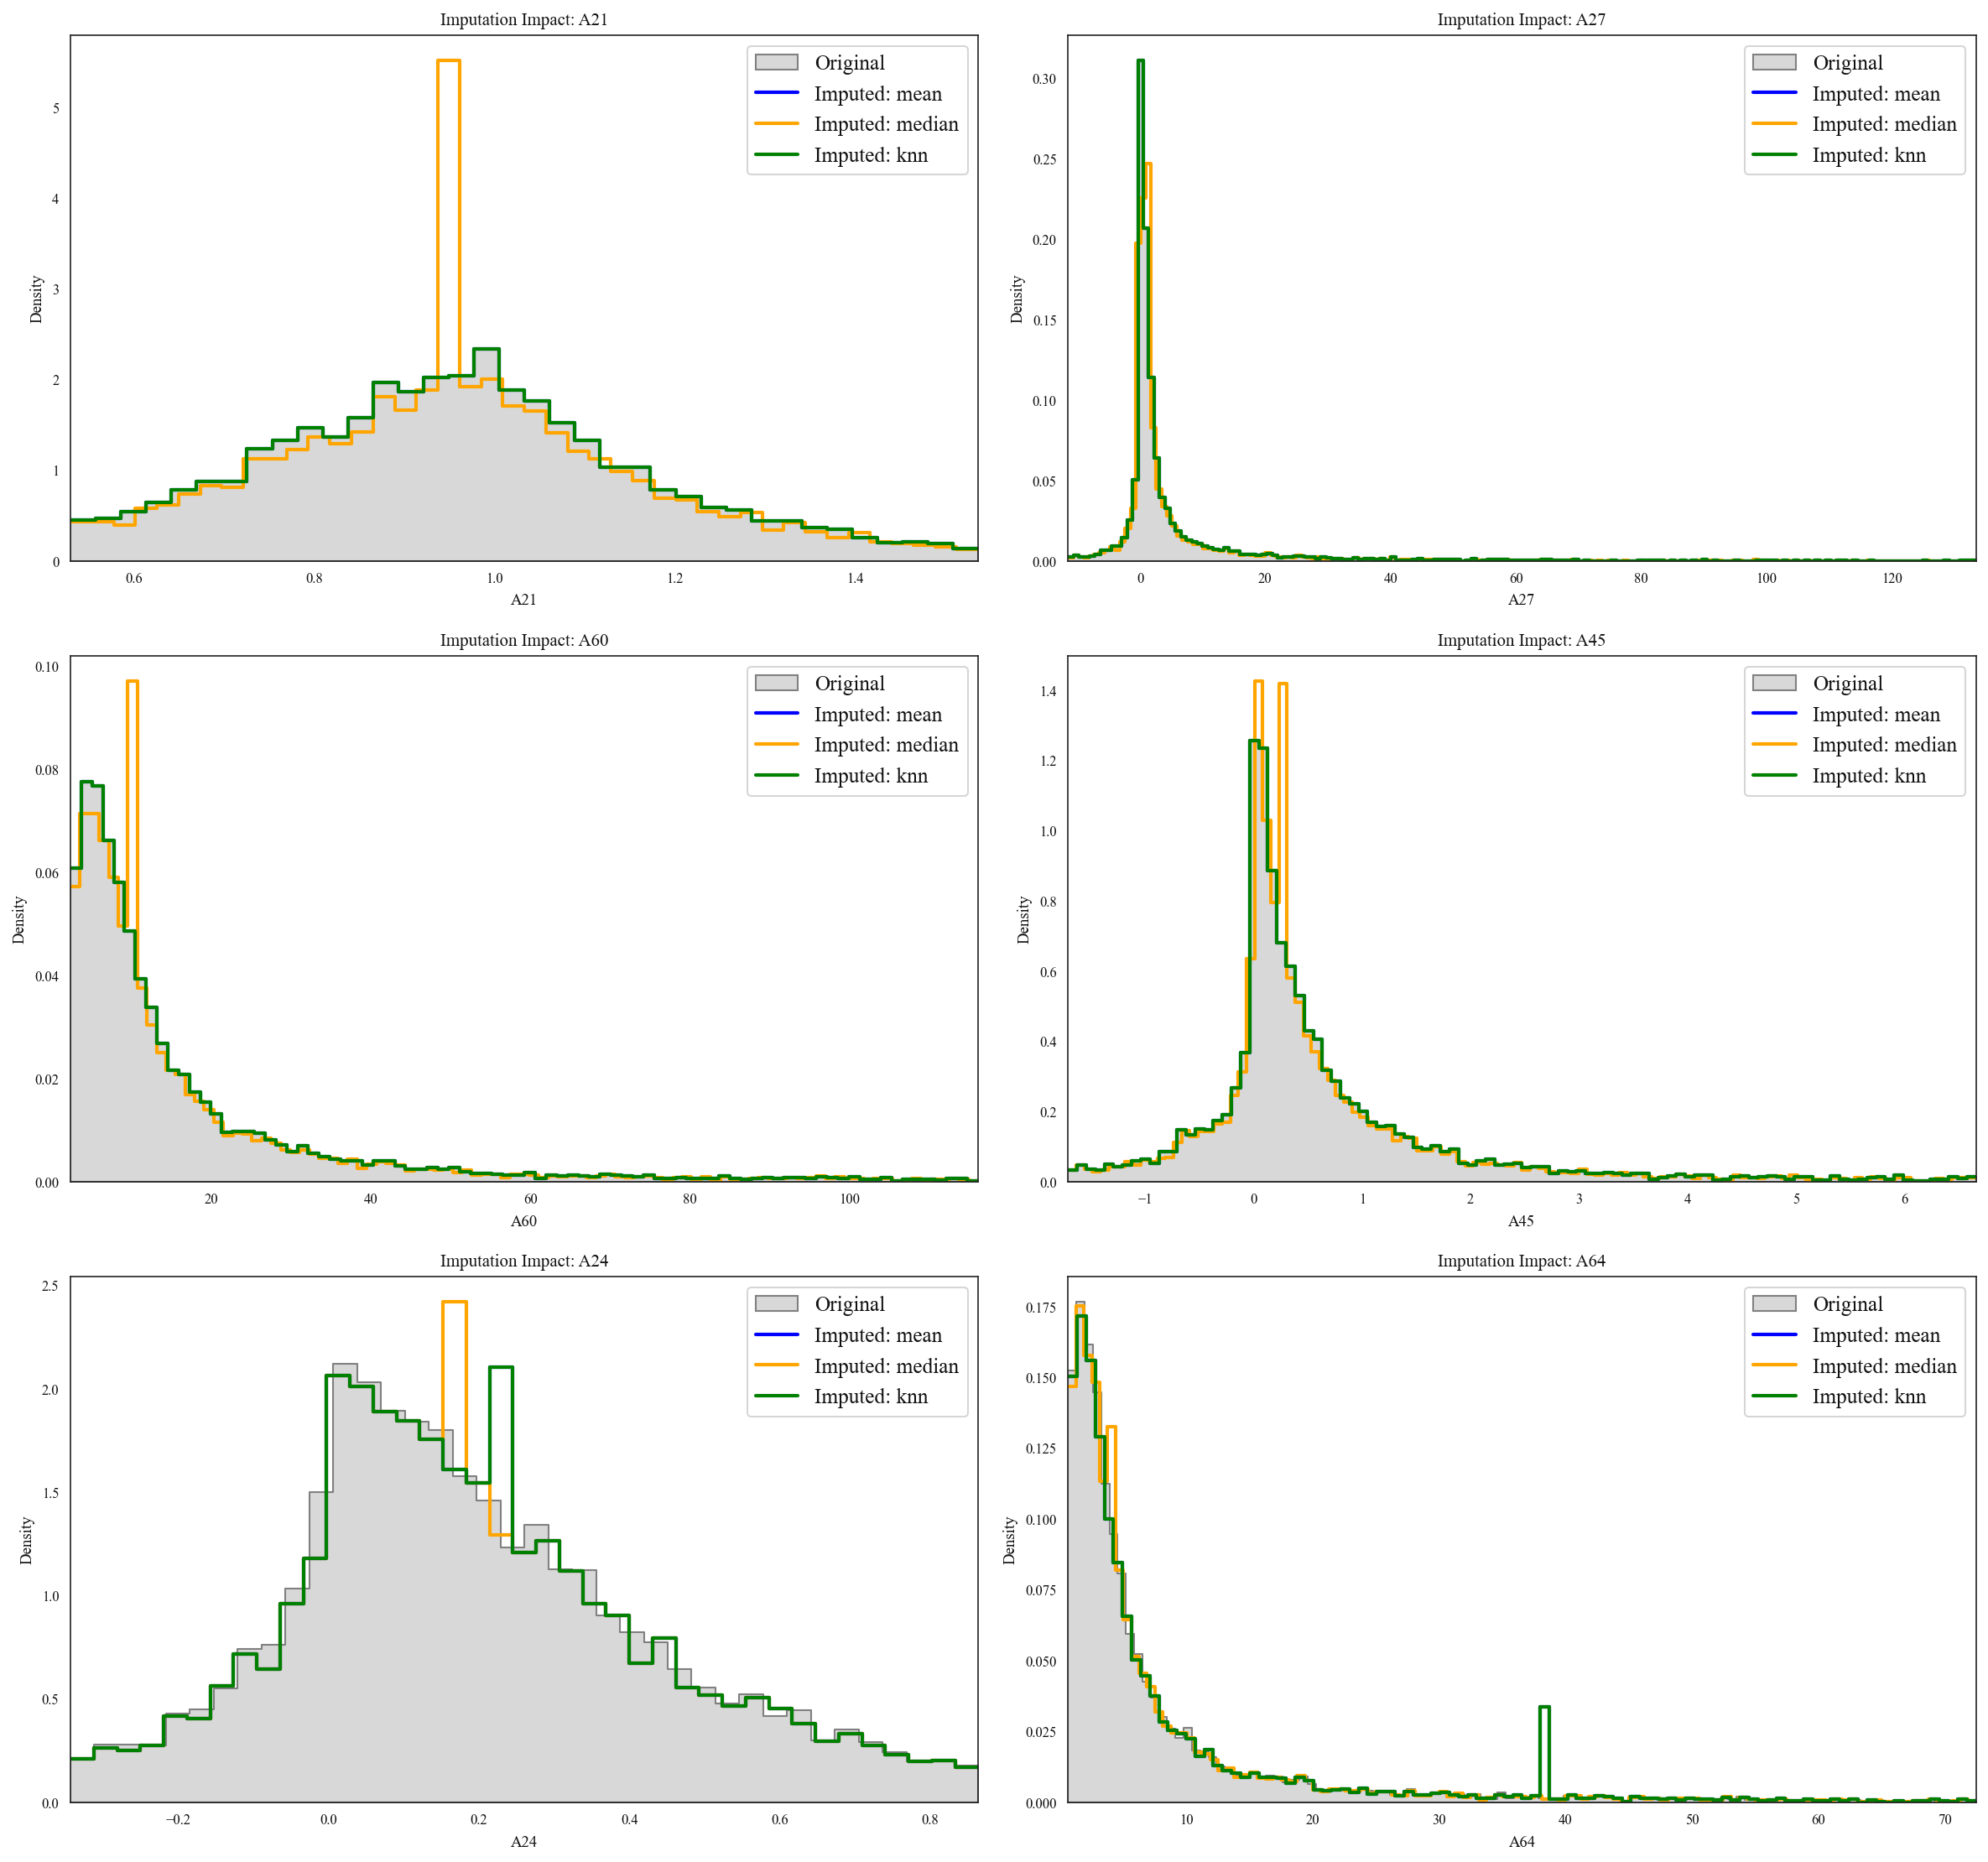

In [173]:
n_cols = 2
n_rows = (len(top_k_features) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(top_k_features):
    ax = axes[i]
    lower, upper = X_train[feature].quantile([0.05, 0.95])

    sns.histplot(
        X_train[feature],
        ax=ax,
        label="Original",
        color="gray",
        alpha=0.3,
        element="step",
        stat="density",
        binrange=(lower, upper),
    )

    colors = {"mean": "blue", "median": "orange", "knn": "green"}

    for name, imputer in IMPUTERS.items():
        imputed_values = imputer.fit_transform(X_train[[feature]]).flatten()
        sns.histplot(
            imputed_values,
            ax=ax,
            label=f"Imputed: {name}",
            element="step",
            fill=False,
            stat="density",
            color=colors[name],
            binrange=(lower, upper),
            linewidth=2,
        )

    ax.set_title(f"Imputation Impact: {feature}")
    ax.set_xlim(lower, upper)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

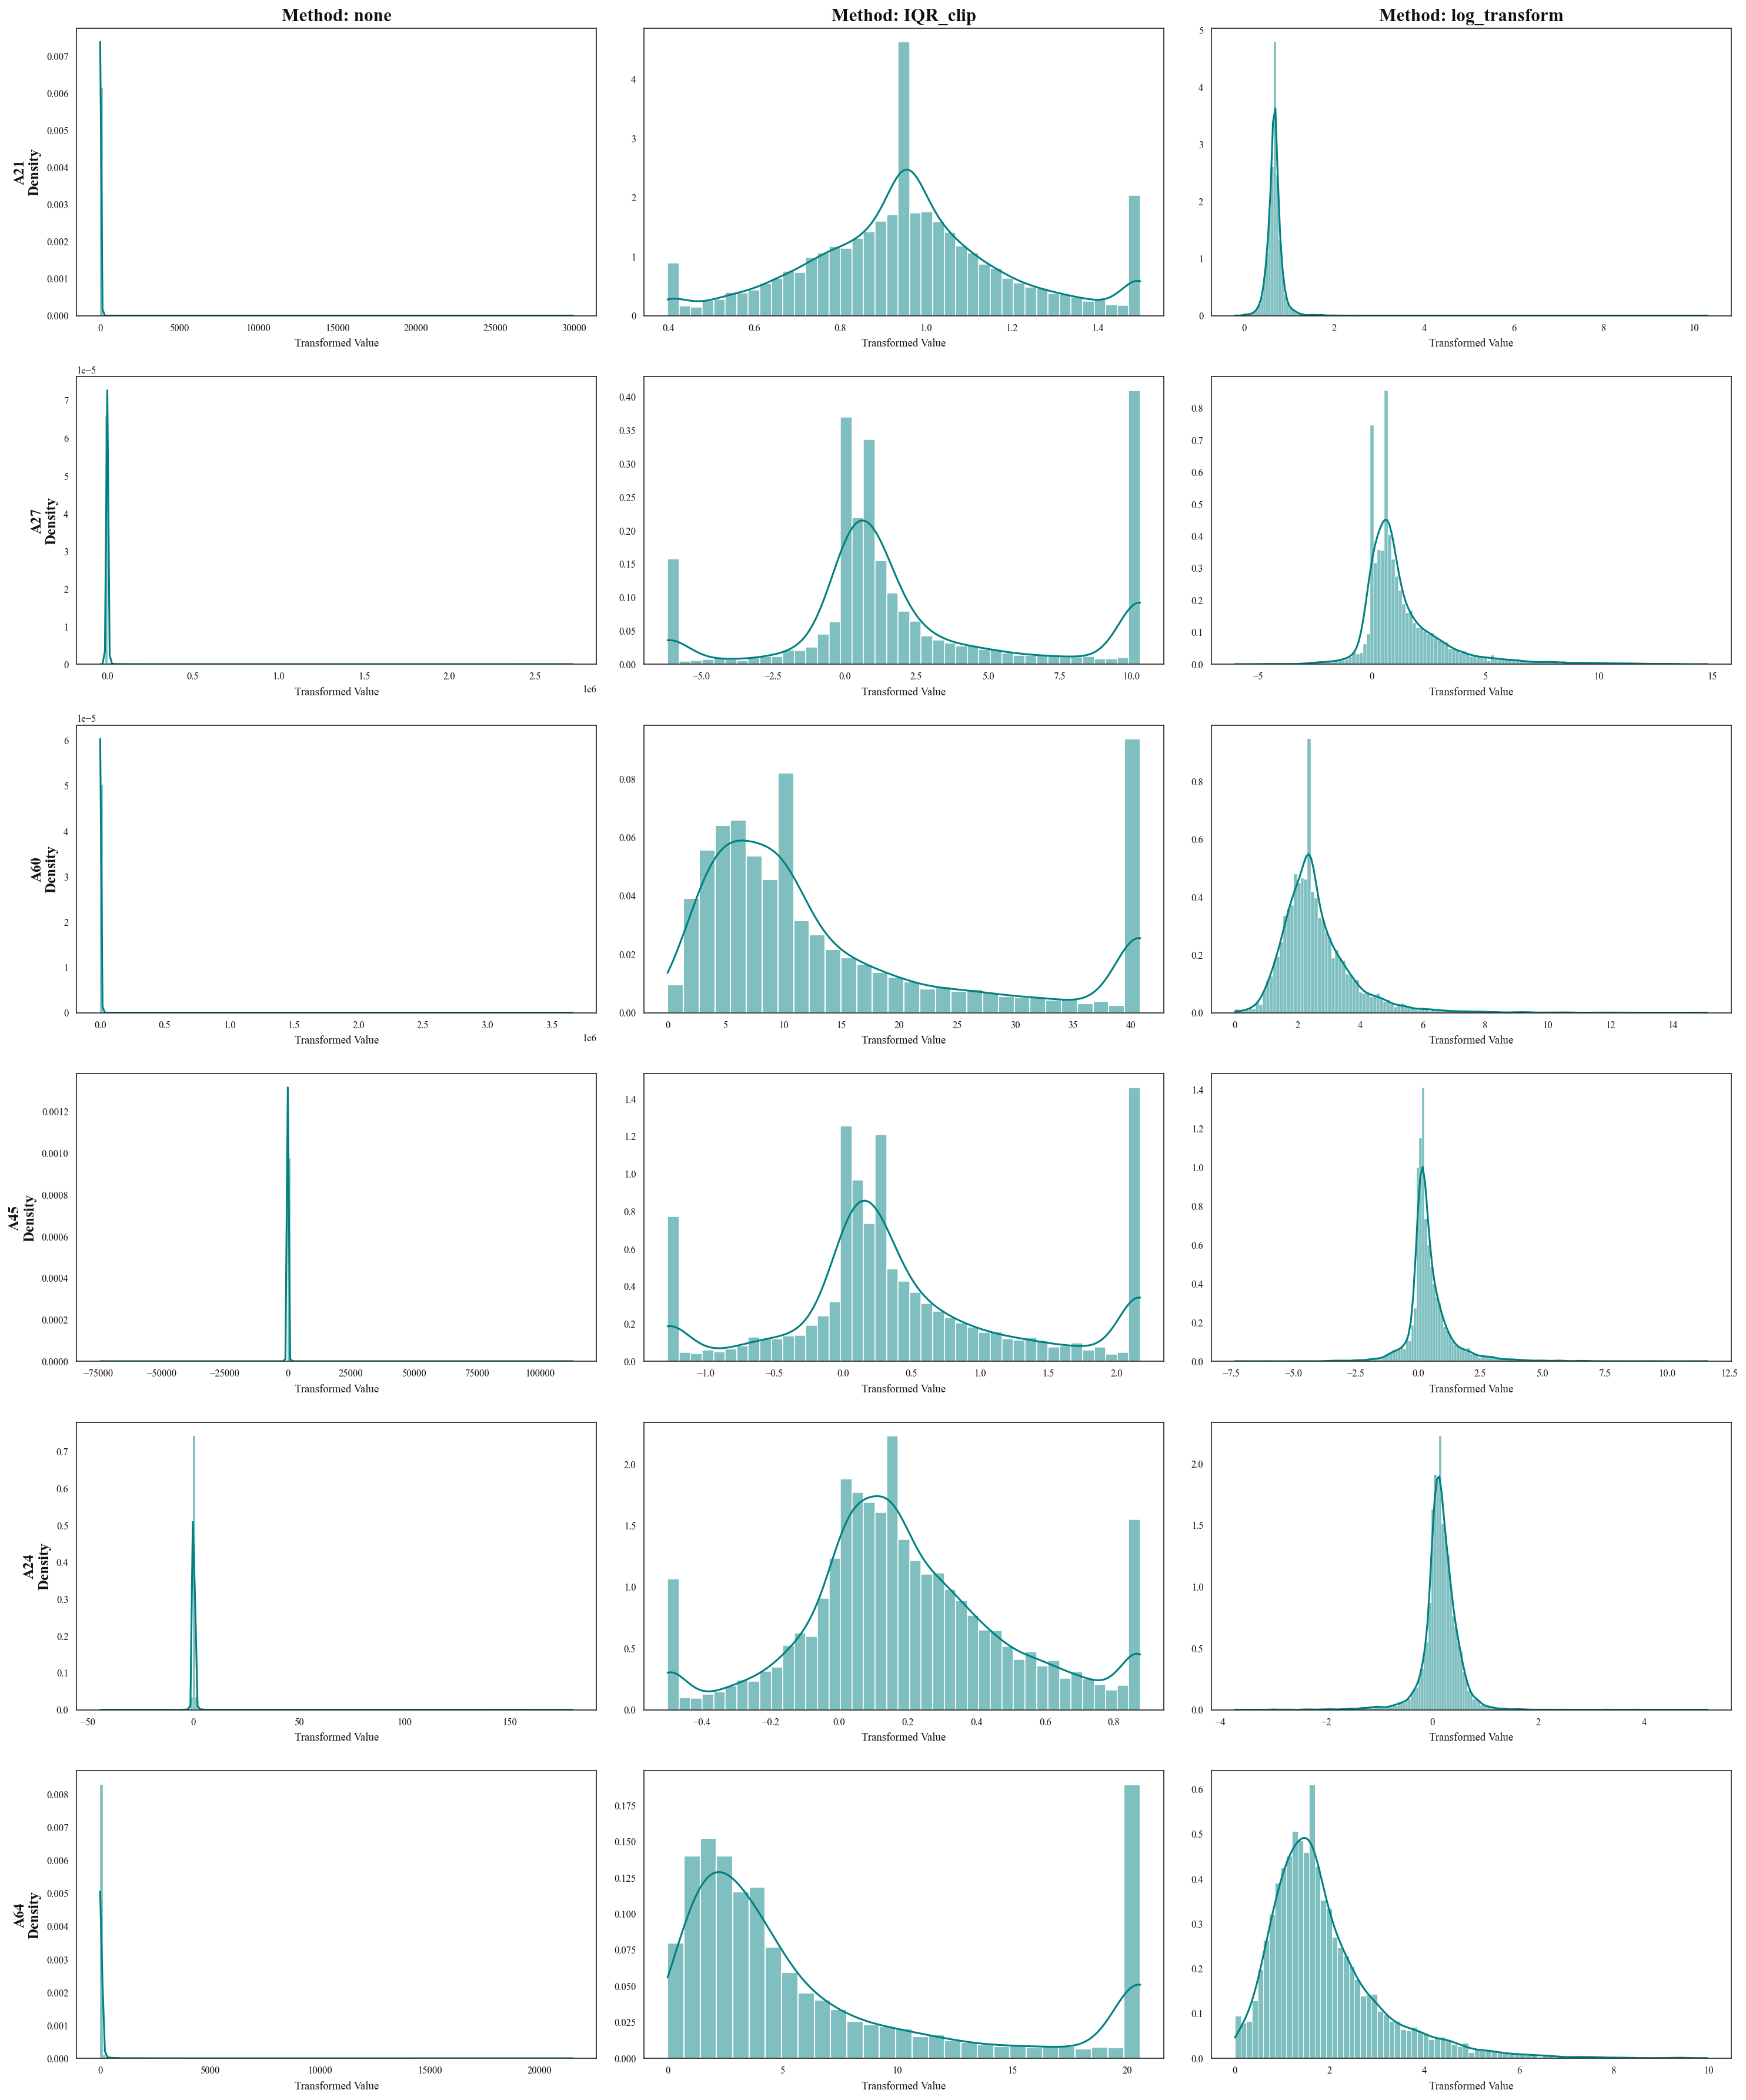

In [174]:
base_imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    base_imputer.fit_transform(X_train[top_k_features]), columns=top_k_features
)

n_features = len(top_k_features)
n_methods = len(OUTLIERS)

fig, axes = plt.subplots(n_features, n_methods, figsize=(20, n_features * 4))

for row_idx, feature in enumerate(top_k_features):
    data_to_transform = X_imputed[[feature]].values

    for col_idx, (method_name, transformer) in enumerate(OUTLIERS.items()):
        ax = axes[row_idx, col_idx]

        transformed_data = transformer.fit_transform(data_to_transform).flatten()

        sns.histplot(transformed_data, kde=True, ax=ax, color="teal", stat="density")

        if row_idx == 0:
            ax.set_title(f"Method: {method_name}", fontsize=15, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"{feature}\nDensity", fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")
        ax.set_xlabel("Transformed Value")


plt.tight_layout()
plt.show()

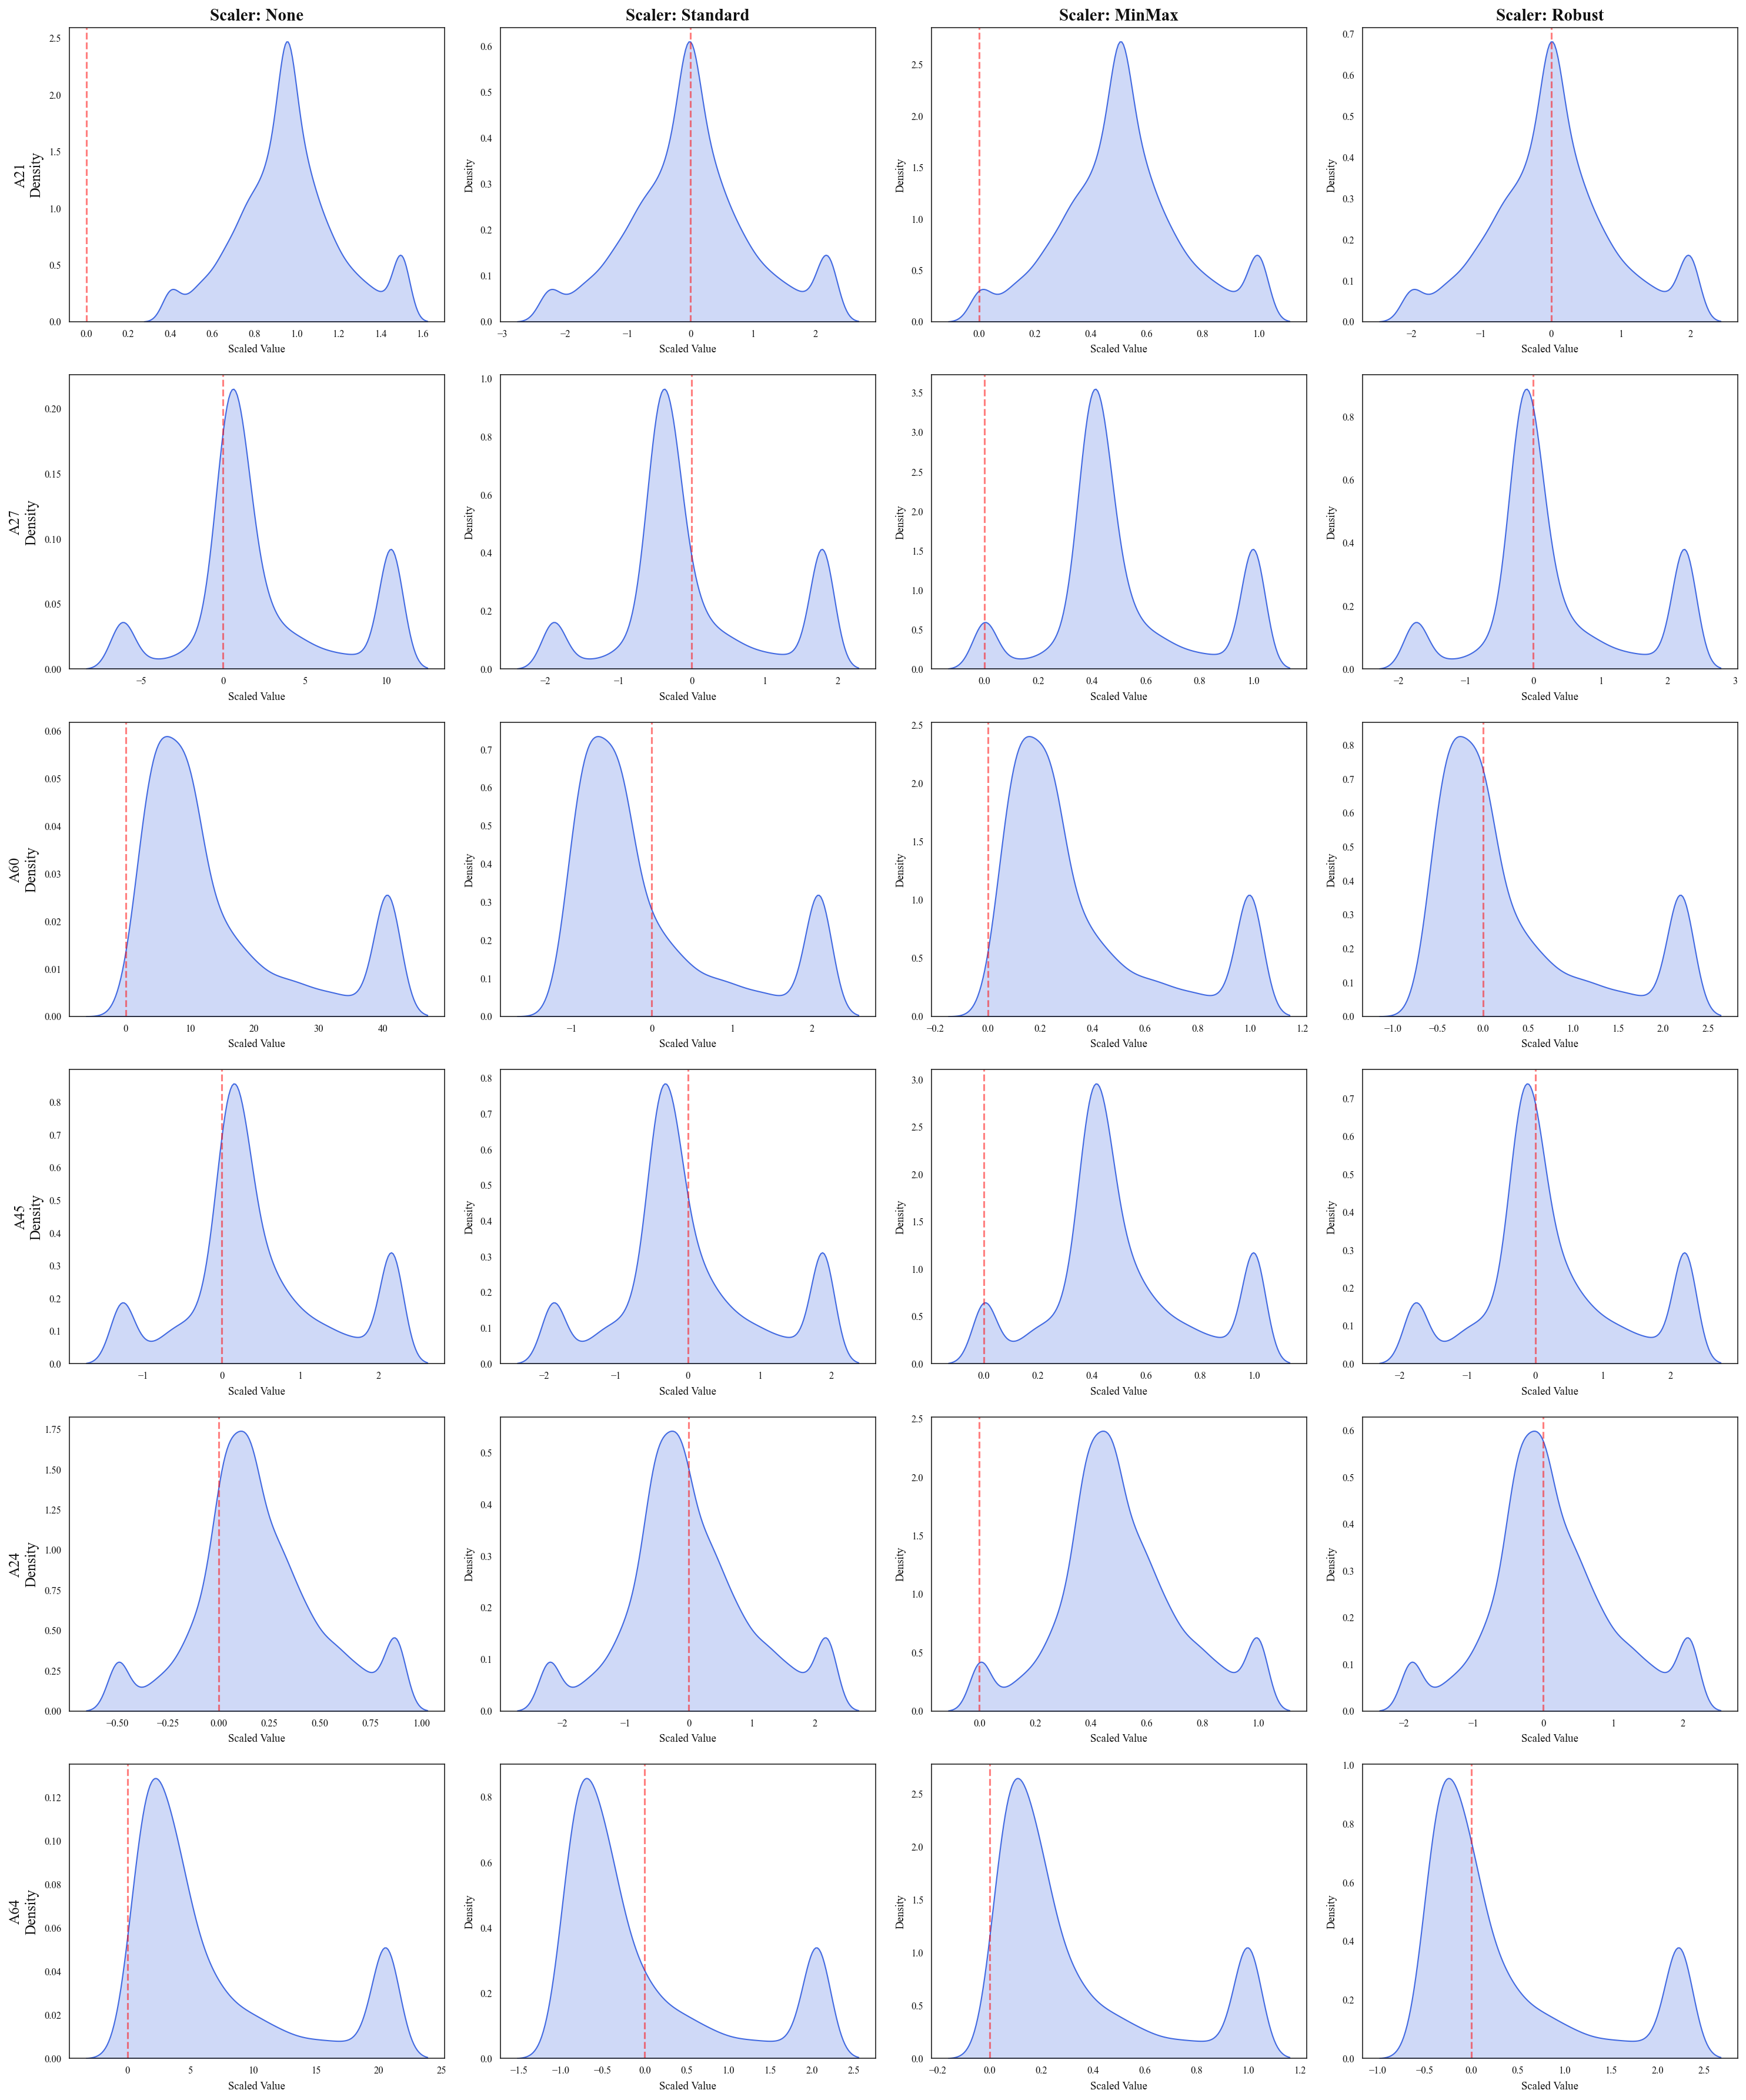

In [175]:
prep_imputer = SimpleImputer(strategy="median")
prep_transformer = IQRClipper(k=1.5)

X_prepped = prep_imputer.fit_transform(X_train[top_k_features])
X_prepped = prep_transformer.fit_transform(X_prepped)
X_prepped = pd.DataFrame(X_prepped, columns=top_k_features)

SCALERS = {
    "None": PassthroughTransformer(),
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler(),
    "Robust": RobustScaler(),
}

n_features = len(top_k_features)
n_scalers = len(SCALERS)

fig, axes = plt.subplots(n_features, n_scalers, figsize=(20, n_features * 4))

for row_idx, feature in enumerate(top_k_features):
    data_to_scale = X_prepped[[feature]].values

    for col_idx, (name, scaler) in enumerate(SCALERS.items()):
        ax = axes[row_idx, col_idx]
        scaled_data = scaler.fit_transform(data_to_scale).flatten()
        sns.kdeplot(scaled_data, ax=ax, fill=True, color="royalblue")
        ax.axvline(0, color="red", linestyle="--", alpha=0.5)

        if row_idx == 0:
            ax.set_title(f"Scaler: {name}", fontsize=14, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"{feature}\nDensity", fontsize=12)

        ax.set_xlabel("Scaled Value")

plt.tight_layout()
plt.show()

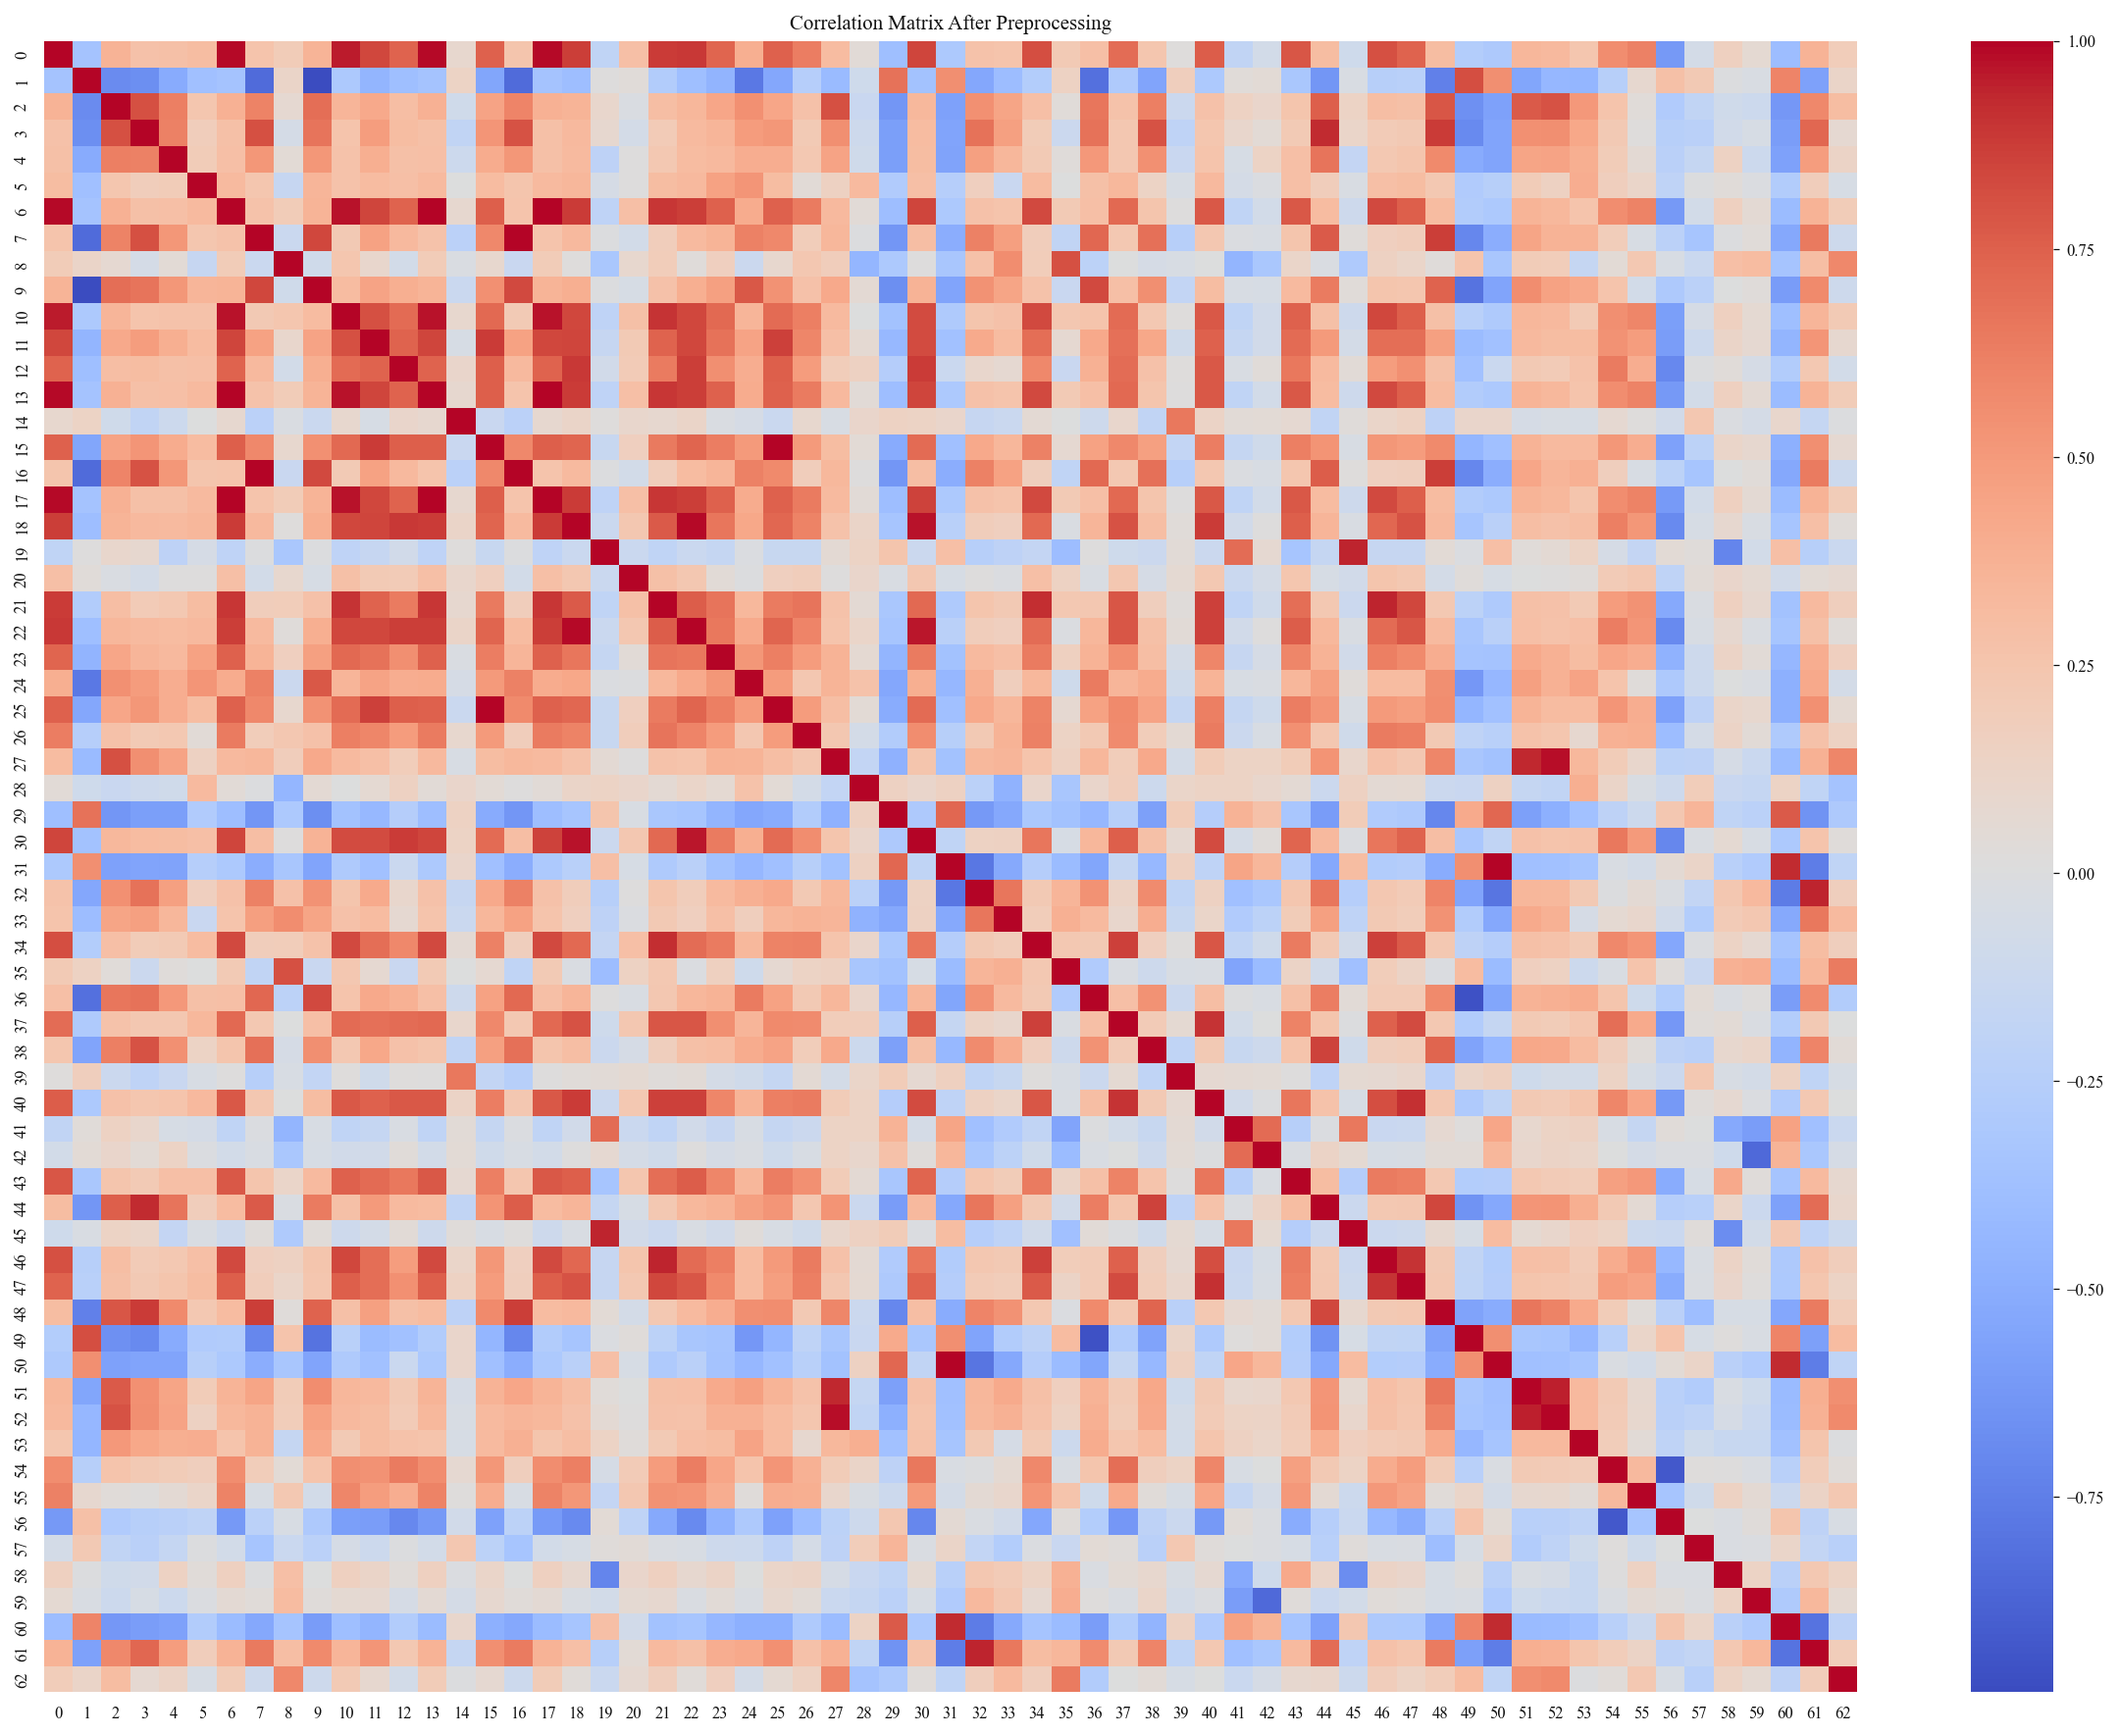

In [176]:
prep_imputer = SimpleImputer(strategy="median")
prep_transformer = IQRClipper(k=1.5)
scaler = StandardScaler()

X_prepped = prep_imputer.fit_transform(X_train)
X_prepped = prep_transformer.fit_transform(X_prepped)
X_prepped = scaler.fit_transform(X_prepped)
X_prepped = pd.DataFrame(X_prepped)
corr = X_prepped.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix After Preprocessing")
plt.tight_layout()
plt.show()

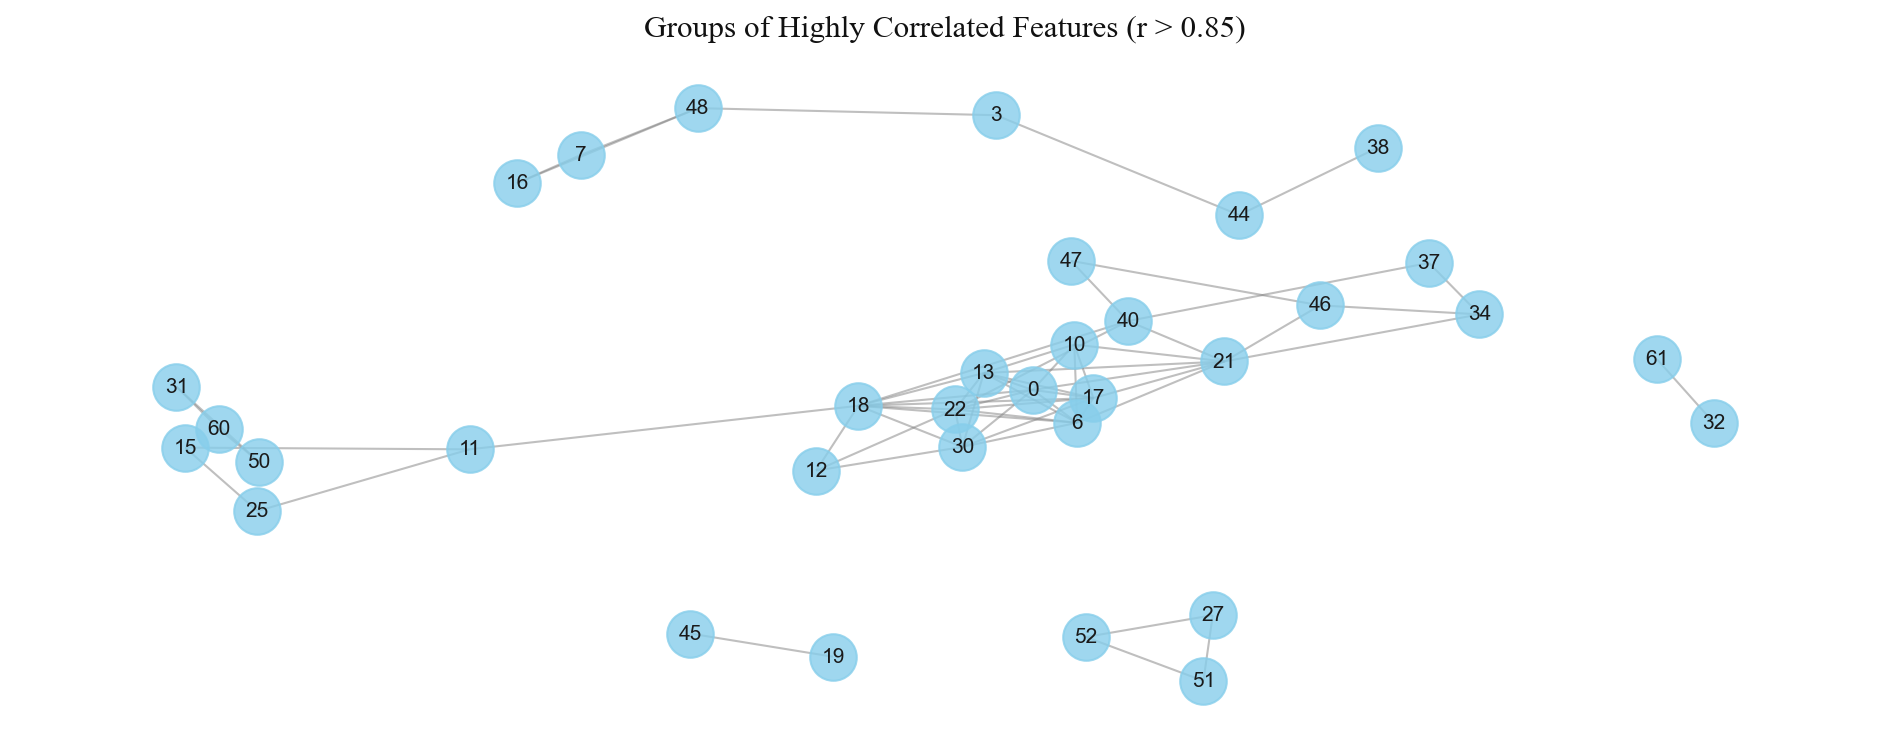

Detected Groups of Correlated Features:
Group 1: [0, 6, 10, 11, 12, 13, 15, 17, 18, 21, 22, 25, 30, 34, 37, 40, 46, 47]
Group 2: [3, 7, 16, 38, 44, 48]
Group 3: [19, 45]
Group 4: [27, 51, 52]
Group 5: [31, 50, 60]
Group 6: [32, 61]


In [177]:
threshold = 0.85
links = corr.stack().reset_index()
links.columns = ["var1", "var2", "value"]
links_filtered = links[(links["value"] > threshold) & (links["var1"] != links["var2"])]

G = nx.from_pandas_edgelist(links_filtered, "var1", "var2")

plt.figure(figsize=(16, 6))
pos = nx.spring_layout(G, k=0.5)

nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue", alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1.0, edge_color="gray", alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")

plt.title(f"Groups of Highly Correlated Features (r > {threshold})", size=15)
plt.axis("off")
plt.show()

print("Detected Groups of Correlated Features:")
groups = list(connected_components(G))
for i, group in enumerate(groups, 1):
    print(f"Group {i}: {sorted(list(group))}")

___

PCA

In [178]:
X_train, X_test, y_train, y_test = train_test_split(
    X.drop(columns=["class"]),
    X["class"],
    test_size=0.2,
    stratify=X["class"],
    random_state=42,
)

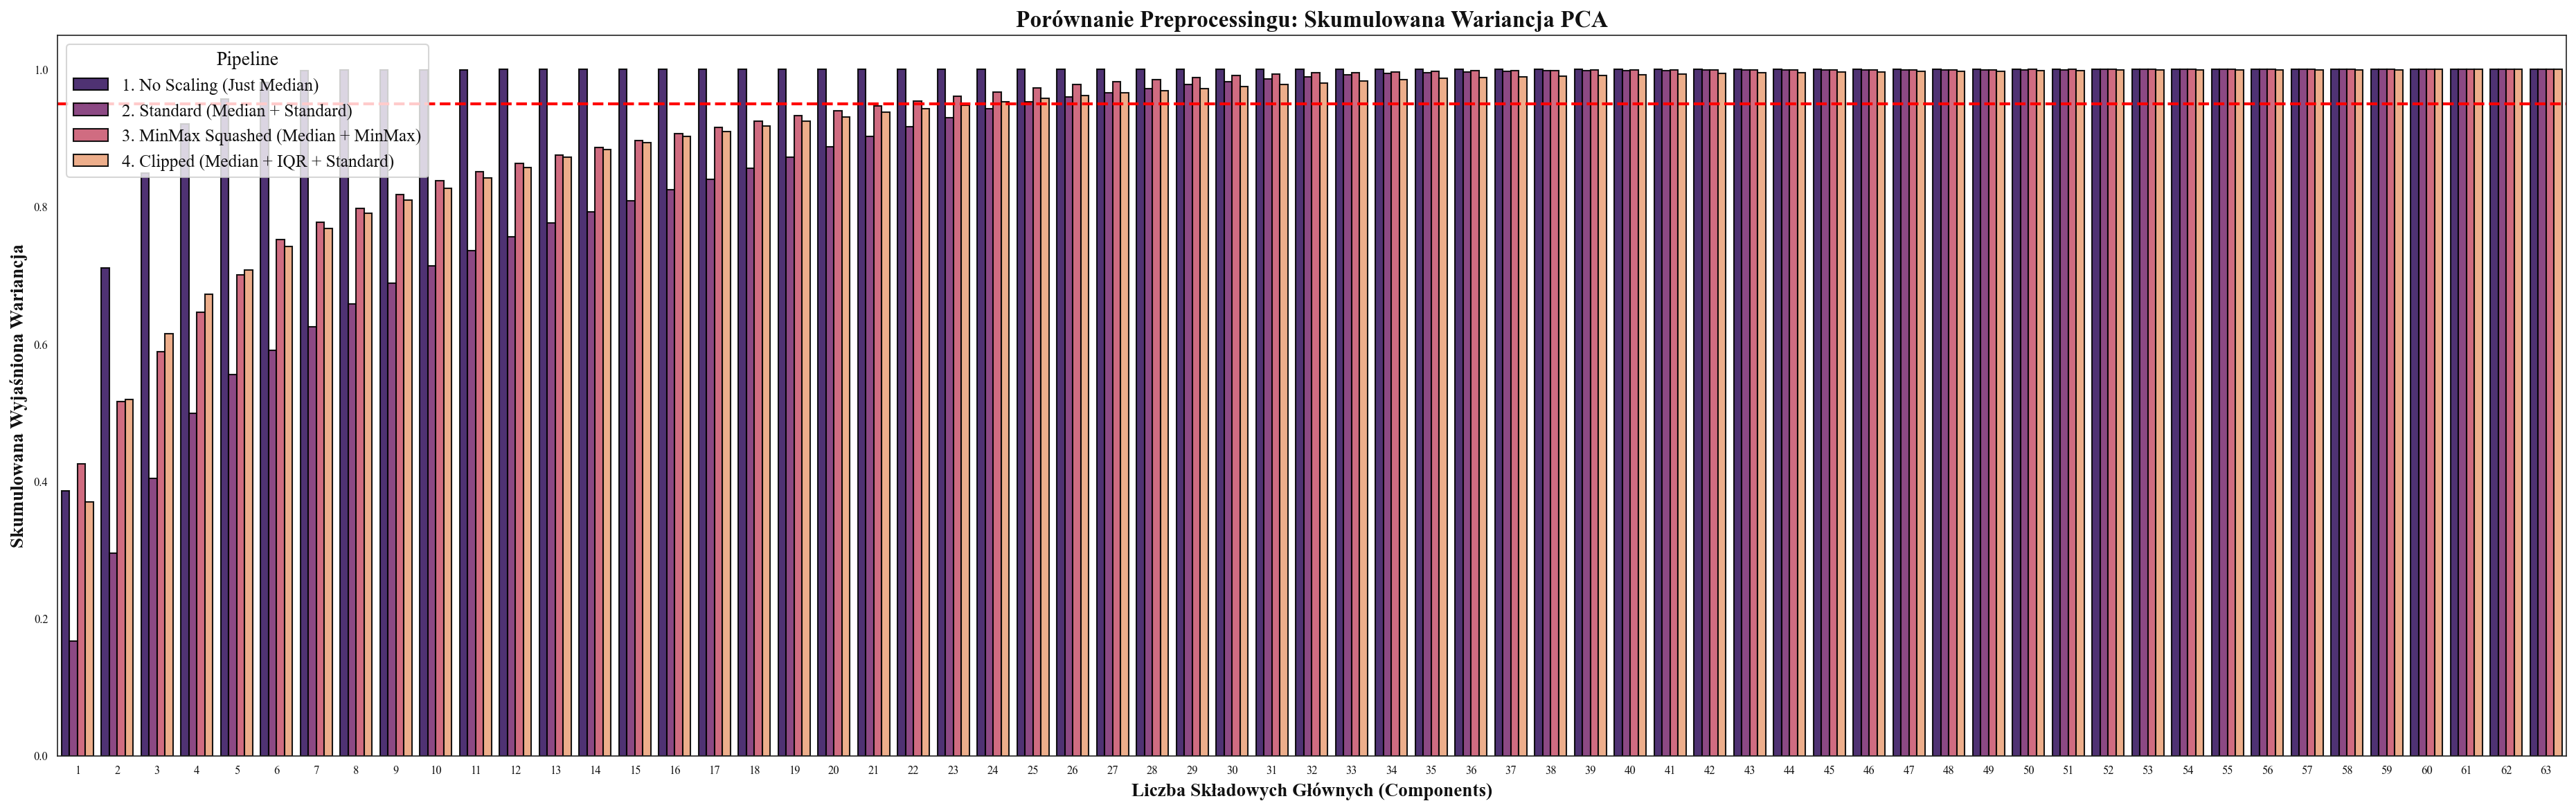

In [179]:
pipelines = {
    "1. No Scaling (Just Median)": Pipeline(
        [("imputer", SimpleImputer(strategy="median"))]
    ),
    "2. Standard (Median + Standard)": Pipeline(
        [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    ),
    "3. MinMax Squashed (Median + MinMax)": Pipeline(
        [("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]
    ),
    "4. Clipped (Median + IQR + Standard)": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("clipper", IQRClipper(k=1.5)),
            ("scaler", StandardScaler()),
        ]
    ),
}

results = []


for name, pipeline in pipelines.items():
    X_processed = pipeline.fit_transform(X_train)
    pca = PCA()
    pca.fit(X_processed)

    cumsum = np.cumsum(pca.explained_variance_ratio_)
    d = np.argmax(cumsum >= 0.95) + 1

    for comp_idx, variance in enumerate(cumsum):
        results.append(
            {
                "Pipeline": f"{name}",
                "Component": comp_idx + 1,
                "Cumulative Variance": variance,
            }
        )

df_pca = pd.DataFrame(results)

plt.figure(figsize=(25, 8))

ax = sns.barplot(
    data=df_pca,
    x="Component",
    y="Cumulative Variance",
    hue="Pipeline",
    palette="magma",
    edgecolor="black",
    alpha=0.9,
)

plt.axhline(y=0.95, color="red", linestyle="--", linewidth=2, label="95% Threshold")
plt.xlabel("Liczba Składowych Głównych (Components)", fontsize=13, fontweight="bold")
plt.ylabel("Skumulowana Wyjaśniona Wariancja", fontsize=13, fontweight="bold")
plt.title(
    "Porównanie Preprocessingu: Skumulowana Wariancja PCA",
    fontsize=16,
    fontweight="bold",
)


plt.tight_layout()
plt.show()

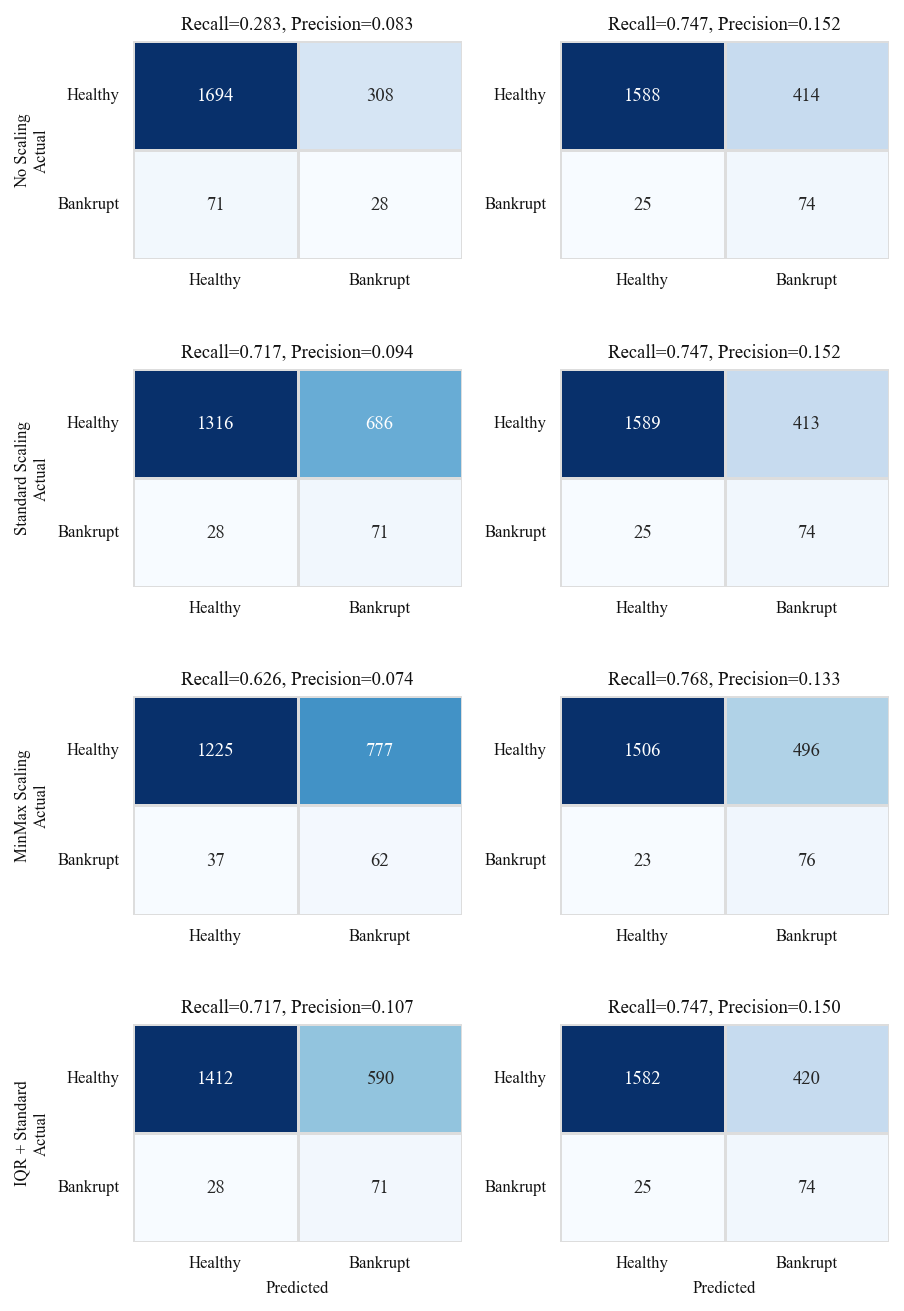

In [180]:
rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "figure.dpi": 150,
    }
)

pipelines = {
    "No Scaling": Pipeline([("imputer", SimpleImputer(strategy="median"))]),
    "Standard Scaling": Pipeline(
        [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    ),
    "MinMax Scaling": Pipeline(
        [("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]
    ),
    "IQR + Standard": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("clipper", IQRClipper(k=1.5)),
            ("scaler", StandardScaler()),
        ]
    ),
}

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42
    ),
    "Decision Tree": RandomForestClassifier(
        max_depth=5, class_weight="balanced", random_state=42
    ),
}

n_rows, n_cols = len(pipelines), len(models)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5, 2.6 * n_rows))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

for row_idx, (pipe_name, pipeline) in enumerate(pipelines.items()):
    X_tr = pipeline.fit_transform(X_train)
    X_te = pipeline.transform(X_test)

    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes[row_idx, col_idx]

        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)

        cm = confusion_matrix(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax,
            linewidths=0.5,
            linecolor="#dddddd",
            annot_kws={"size": 9},
        )

        ax.set_title(
            f"Recall={recall:.3f}, Precision={precision:.3f}", fontsize=9, pad=6
        )
        ax.set_xticklabels(["Healthy", "Bankrupt"], fontsize=8)
        ax.set_yticklabels(["Healthy", "Bankrupt"], fontsize=8, rotation=0)

        ax.set_xlabel("Predicted" if row_idx == n_rows - 1 else "", fontsize=8)
        ax.set_ylabel(f"{pipe_name}\nActual" if col_idx == 0 else "", fontsize=8)

plt.show()